# IQB-Edu: Internet Connectivity Analysis for MD Schools (January 2026)

This notebook analyzes Internet connectivity data for schools in **Moldova (MD)** for **January 2026**, using the **Internet Quality Barometer (IQB)**. 

## 1. Setup

Imports: `iqbedu` for loading school data, `iqb` for score calculation, `pandas`/`itertools` for data manipulation, `matplotlib`/`plotly` for visualization.

In [2]:
from iqbedu.data import IQBEduData
from iqb.calculator import IQBCalculator, IQB_CONFIG
import os
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import copy
import itertools

## 2. Data Loading

Load pre-computed per-school measurement percentiles from the M-Lab cache for January 2026. Each row represents one school; columns contain percentiles (1, ..., 99) for download/pupload throughput, latency, packet loss derived from NDT speed tests collected during the month.

*Note:* Only schools with sufficient sample counts should be retained for analysis (TODO for future analysis).

In [3]:
# Load per-school percentile data for January 2026
STATS_DATA_PATH = "./data/IQB_Edu_MD_2026-01-01_2026-02-01_stats.csv"
df_stats = pd.read_csv(STATS_DATA_PATH)
data = IQBEduData(df=df_stats)
print(f"{len(data.schools)} schools")

57 schools


In [4]:
data.df.head()

,school_id,giga_id_school,download_sample_count,download_p1,download_p5,download_p10,download_p25,download_p50,download_p75,download_p90,...,upload_sample_count,upload_p1,upload_p5,upload_p10,upload_p25,upload_p50,upload_p75,upload_p90,upload_p95,upload_p99
0,0b902bf9-e528-3ad6-9cff-f6a998837d5c,0b902bf9-e528-3ad6-9cff-f6a998837d5c,48,67.447101,80.088146,83.514290,87.362739,90.217335,91.280499,91.784878,...,48,2.642213,89.482078,90.888058,91.877584,92.205473,92.607260,92.698335,92.807899,92.902166
1,1923d37f-19ca-30bd-9ace-a15a1da77539,1923d37f-19ca-30bd-9ace-a15a1da77539,100,47.104019,82.960344,85.276588,90.300451,93.622419,552.161581,696.600455,...,100,44.367051,61.208593,67.982598,80.061570,92.470952,741.360001,882.198125,915.666783,918.439277
2,1f9fe5fe-b155-3bb1-b52e-c30507601942,1f9fe5fe-b155-3bb1-b52e-c30507601942,80,0.419917,1.529998,2.588743,6.918762,37.182224,58.270923,63.011221,...,80,1.040739,3.428545,5.993673,12.707987,28.755671,59.399754,68.193193,70.379667,72.157728
3,24a65046-6dcc-3860-865f-2528131a5c75,24a65046-6dcc-3860-865f-2528131a5c75,88,2.609435,10.116861,29.936333,80.718837,86.428946,87.068643,87.456412,...,88,0.545999,5.203868,33.664127,67.168632,86.876808,92.524728,93.119546,93.172669,93.268336
4,25701868-5891-3cd2-9e9c-9fbea33d4459,25701868-5891-3cd2-9e9c-9fbea33d4459,70,91.586231,91.664559,410.658204,444.643870,525.218337,638.943483,665.372558,...,70,47.430210,92.731654,147.207288,489.476631,560.150687,633.388852,665.758701,669.766715,673.749125


## 3. IQB Score Computation

Compute the IQB composite score for each school using five **aggregation percentiles** (p25, p50, p75, p90, p95). Each percentile represents a different connectivity "scenario":

| Percentile | Interpretation |
|------------|---------------|
| p25 | Conservative / worst-quarter experience |
| p50 | Typical (median) experience |
| p75 | Above-average experience |
| p90 | Near-peak experience |
| p95 | Best-case experience |

In [5]:
# Compute IQB scores at different percentiles for all schools
calc = IQBCalculator()
PERCENTILES = [25,50,75,90,95]
scores = []
for school_id in data.schools:
    score = {"school_id": school_id}
    for perc in PERCENTILES:
        mlab_data = data.to_iqb_data(school_id, percentile=perc)
        score[f"iqb_score_p{perc}"] = calc.calculate_iqb_score({"m-lab": mlab_data.to_dict()})
    scores.append(score)

# add number of samples in the dataframe
scores_df = pd.DataFrame(scores)
scores_df = pd.merge(scores_df, data.sample_counts[["school_id","download_sample_count"]], on="school_id", how="outer")
scores_df = scores_df.sort_values("iqb_score_p50")#, ascending=False)

scores_df = pd.merge(
    scores_df,
    data.df[["school_id", "giga_id_school"]],
    on="school_id",
    how="left",
)

scores_df.head()



,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count,giga_id_school
0,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.178266,0.178266,0.319902,0.319902,0.319902,6,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad
1,df15772b-217b-3d5d-8898-b1b7e20676b8,0.206044,0.206044,0.773028,0.822479,0.822479,205,df15772b-217b-3d5d-8898-b1b7e20676b8
2,aa38e9c9-4df9-3306-b3cd-dec912477051,0.178266,0.219933,0.668022,0.668022,0.668022,6,aa38e9c9-4df9-3306-b3cd-dec912477051
3,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.178266,0.369353,0.369353,0.369353,0.369353,27,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e
4,a67185fb-a84d-3cf2-9be5-052e04d00716,0.227717,0.369353,0.411020,0.411020,0.613095,47,a67185fb-a84d-3cf2-9be5-052e04d00716


### 3.1 Which percentiles to use?

- **p25**: Worst-case experience
- **p50**: Average experience
- **p95**: Best-case experience


Notes:
- p90 and p95 have similar patterns; when enough data consider using p95
- p75 bring some extra information (low/mid correlation with other percentiles), however, not clear how to interpet it
- IQB scores are not correlated with number of samples (good); more analysis below

In [6]:
scores_df[[c for c in scores_df.columns if c not in ('school_id', 'giga_id_school')]].corr().round(2)

,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count
iqb_score_p25,1.00,0.55,0.11,0.16,0.12,-0.09
iqb_score_p50,0.55,1.00,0.61,0.58,0.56,-0.02
iqb_score_p75,0.11,0.61,1.00,0.79,0.72,0.30
iqb_score_p90,0.16,0.58,0.79,1.00,0.86,0.22
iqb_score_p95,0.12,0.56,0.72,0.86,1.00,0.19
download_sample_count,-0.09,-0.02,0.30,0.22,0.19,1.00


Each scatter plot compares IQB scores computed at two different percentiles across all schools. Points on the diagonal indicate schools whose score is _stable_ regardless of the percentile used. Points far from the diagonal reveal schools with _high connectivity variability_ (see analysis in **Section 3.3**)

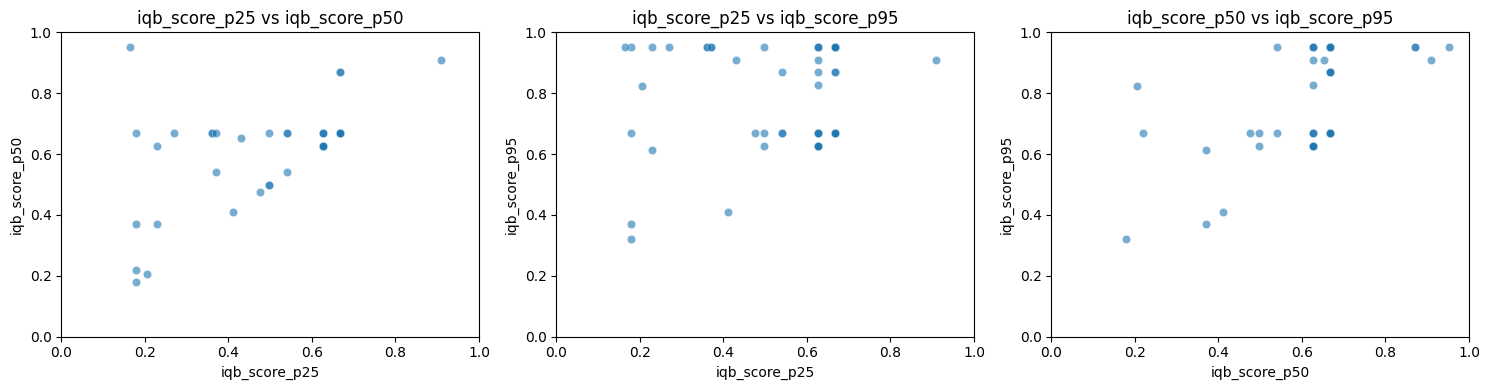

In [7]:
# Get all iqb columns
iqb_cols = [col for col in scores_df.columns if col.startswith('iqb')]

# Get all combinations
# combos = list(itertools.combinations(iqb_cols, 2))
# Get most meaningful combinations
combos = [('iqb_score_p25', 'iqb_score_p50'),
          ('iqb_score_p25', 'iqb_score_p95'),
          ('iqb_score_p50', 'iqb_score_p95')]

# Set up the grid
n = len(combos)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(combos):
    ax = axes[i]
    ax.scatter(scores_df[x_col], scores_df[y_col], alpha=0.6, edgecolors='w', linewidths=0.4)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Each scatter plot compares IQB scores vs number of samples across all schools. 

- Points on the low part of the y-axis are those with few samples, i.e., not very reliable results
- We see no specific pattern of IQB scores vs nb of samples (good)
- However, some very large or very small IQB values (for p25 and 50) are for schools with few samples
- For p95, there are very high values both for schools with few and many samples

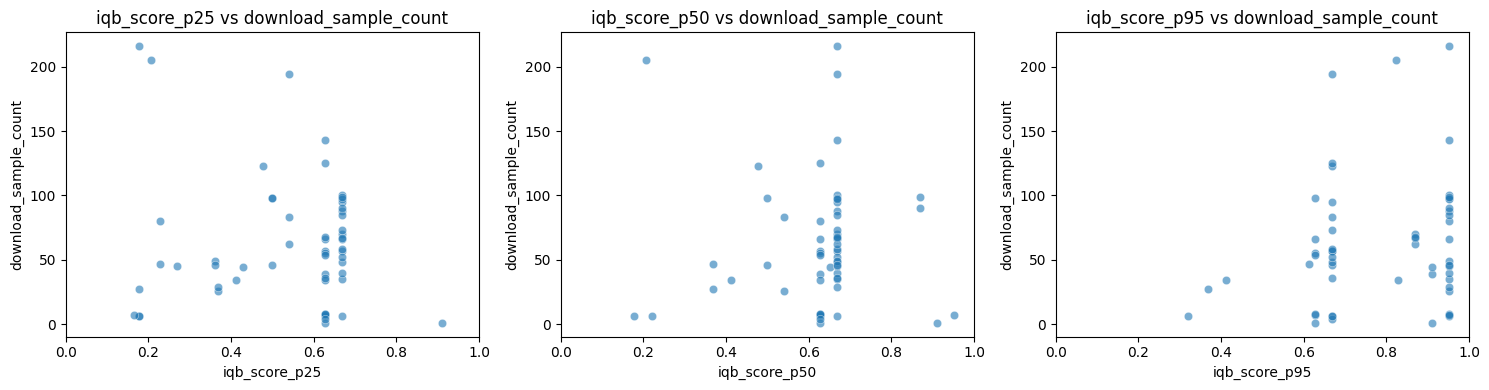

In [8]:
# Get all iqb columns
iqb_cols = [col for col in scores_df.columns if col.startswith('iqb')]

# Get all combinations
# combos = list(itertools.combinations(iqb_cols, 2))
# Get most meaningful combinations
combos = [('iqb_score_p25', 'download_sample_count'),
          ('iqb_score_p50', 'download_sample_count'),
          ('iqb_score_p95', 'download_sample_count')]

# Set up the grid
n = len(combos)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(combos):
    ax = axes[i]
    ax.scatter(scores_df[x_col], scores_df[y_col], alpha=0.6, edgecolors='w', linewidths=0.4)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2: Exploration of IQB scores

Distribution of IQB scores (calculated with different percentiles): CDFs and Histograms 

In [9]:
def get_cdf(ds):
    x_cdf = ds.dropna().sort_values()
    y_cdf = np.arange(1, len(x_cdf) + 1) / len(x_cdf)
    return x_cdf, y_cdf


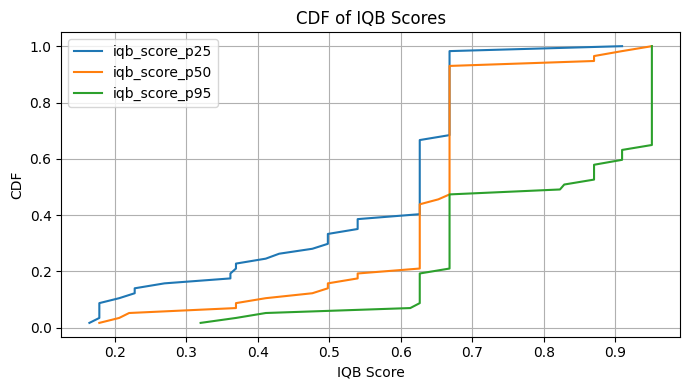

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

for col in ["iqb_score_p25", "iqb_score_p50", "iqb_score_p95"]:
    x_cdf, y_cdf = get_cdf(scores_df[col])
    ax.plot(x_cdf, y_cdf, label=col)

ax.set_xlabel("IQB Score")
ax.set_ylabel("CDF")
ax.set_title("CDF of IQB Scores")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

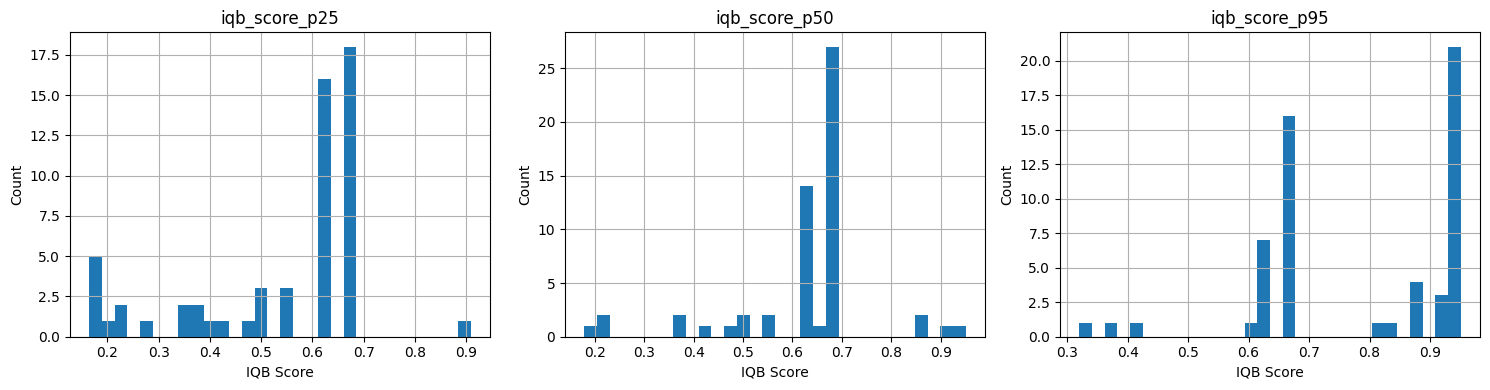

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["iqb_score_p25", "iqb_score_p50", "iqb_score_p95"]):
    ax.hist(scores_df[col].dropna(), bins=30)
    ax.set_xlabel("IQB Score")
    ax.set_ylabel("Count")
    ax.set_title(col)
    ax.grid(True)

plt.tight_layout()
plt.show()


### 3.3: Comparison of Best/Avg/Worst performance - Schools 

Comparing scores across percentiles reveals **connectivity consistency**: schools with similar p25 and p90 scores have stable connections; a large spread indicates high variability.

Findings:
- Around 30% of schools seem to have very reliable connections, the difference between 25th (or 50th) and 95th IQB scores are 0
- As expected the differrence p95-p50 is smaller than p95-p25, however, there are no large differences and distributions follow similar patterns (and correlation is high)
- **Idea**: We could define a "reliability score" where if diff is between [0, X] then connection reliability is "high", if between [X, Y] it is "medium" and if [Y,1] then "low". We need to define the X,Y and which percentiles to consider
- The plots of IQB difference vs number of samples indicate that the results are not due to few measurements. There is not significant correlation.

In [12]:
scores_df['iqb_score_diff_p95_p25'] = scores_df['iqb_score_p95'] -  scores_df['iqb_score_p25']
scores_df['iqb_score_diff_p95_p50'] = scores_df['iqb_score_p95'] -  scores_df['iqb_score_p50']
scores_df.head()

,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count,giga_id_school,iqb_score_diff_p95_p25,iqb_score_diff_p95_p50
0,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.178266,0.178266,0.319902,0.319902,0.319902,6,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.141636,0.141636
1,df15772b-217b-3d5d-8898-b1b7e20676b8,0.206044,0.206044,0.773028,0.822479,0.822479,205,df15772b-217b-3d5d-8898-b1b7e20676b8,0.616435,0.616435
2,aa38e9c9-4df9-3306-b3cd-dec912477051,0.178266,0.219933,0.668022,0.668022,0.668022,6,aa38e9c9-4df9-3306-b3cd-dec912477051,0.489756,0.448089
3,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.178266,0.369353,0.369353,0.369353,0.369353,27,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.191087,0.000000
4,a67185fb-a84d-3cf2-9be5-052e04d00716,0.227717,0.369353,0.411020,0.411020,0.613095,47,a67185fb-a84d-3cf2-9be5-052e04d00716,0.385379,0.243742


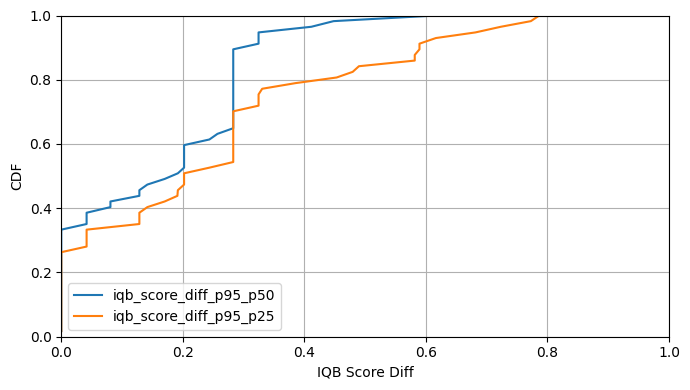

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

for col in ['iqb_score_diff_p95_p50', 'iqb_score_diff_p95_p25']:
    x_cdf, y_cdf = get_cdf(scores_df[col])
    ax.plot(x_cdf, y_cdf, label=col)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('IQB Score Diff')
ax.set_ylabel('CDF')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [14]:
scores_df[["download_sample_count", "iqb_score_diff_p95_p25", "iqb_score_diff_p95_p50"]].corr().round(2)

,download_sample_count,iqb_score_diff_p95_p25,iqb_score_diff_p95_p50
download_sample_count,1.00,0.21,0.24
iqb_score_diff_p95_p25,0.21,1.00,0.74
iqb_score_diff_p95_p50,0.24,0.74,1.00


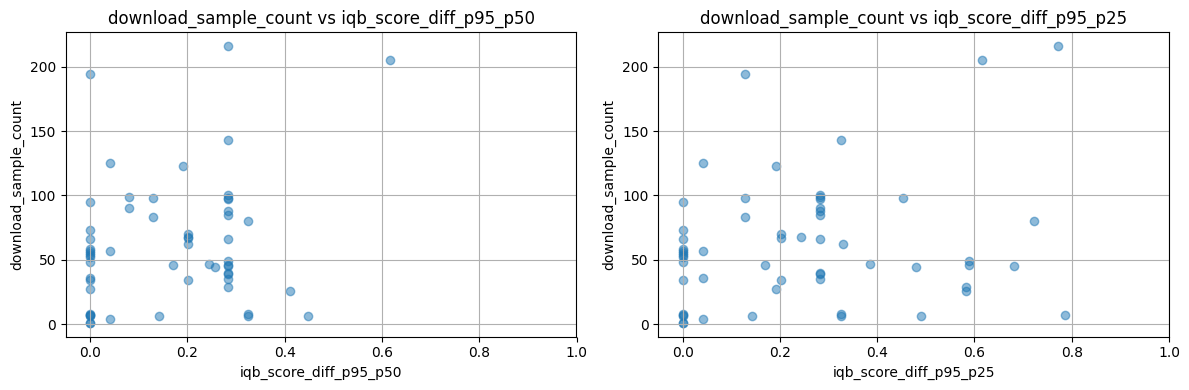

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['iqb_score_diff_p95_p50', 'iqb_score_diff_p95_p25']):
    ax.scatter(scores_df[col], scores_df['download_sample_count'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('download_sample_count')
    ax.set_title(f'download_sample_count vs {col}')
    ax.set_xlim(-0.05, 1)
    ax.grid(True)

plt.tight_layout()
plt.show()

## 4. IQB Score by Use Case

The default IQB score is a weighted average across six use cases. Here we **isolate each use case** by zeroing out the weights of all others, producing a per-use-case IQB score for each school.

This decomposition reveals which applications are best or worst served by each school's connection. For example, a school may score well for **audio streaming** (low bandwidth requirement) but poorly for **video conferencing** (requires both high upload and low latency).

We also calculate a "custom IQB" with the following weights (can be parametrized below)
```json
CUSTOM_CONFIG_WEIGHTS = {
    'online backup':0.5,
    'web browsing':1,
    'audio streaming':0.5,
    'video streaming':1,
    'video conferencing':1,
    'gaming':0}
```

In [16]:
IQB_USE_CASES = [uc for uc in IQB_CONFIG['use cases']]
IQB_USE_CASES

['web browsing',
 'video streaming',
 'audio streaming',
 'video conferencing',
 'online backup',
 'gaming']

In [17]:
SORTED_IQB_USE_CASES = [
    'online backup',
    'web browsing',
    'audio streaming',
    'video streaming',
    'video conferencing',
    'gaming',
    'Custom IQB']

In [18]:
# Create an IQBCalculator per use case (i.e., each calculator takes considers only the corresponding use case and neglects the other use cases --i.e., assigns zero weights to them
# Note: to create an IQBCalculator per use case, we just need to define a different configuration input 
calc_uc = dict()
for uc in IQB_USE_CASES:
    config_uc = copy.deepcopy(IQB_CONFIG)
    for uc1 in IQB_USE_CASES:
        if uc1 != uc:
            config_uc['use cases'][uc1]['w'] = 0
    calc_uc[uc] = IQBCalculator(config = copy.deepcopy(config_uc))

In [19]:
# Compute IQB scores at different use cases and different percentiles for all schools
scores_df_uc = dict()
PERCENTILES = [25,50,95]
for uc in IQB_USE_CASES:
    scores = []
    for school_id in data.schools:
        score = {"school_id": school_id}
        for perc in PERCENTILES:
            mlab_data = data.to_iqb_data(school_id, percentile=perc)
            score[f"iqb_score_p{perc}"] = calc_uc[uc].calculate_iqb_score({"m-lab": mlab_data.to_dict()})
        scores.append(score)

    scores_df_uc[uc] = pd.DataFrame(scores).sort_values("iqb_score_p50", ascending=False)

In [20]:
# Create a custom IQBCalculator with custom / user-defined weights per use case
CUSTOM_CONFIG_WEIGHTS = {
    'online backup':0.5,
    'web browsing':1,
    'audio streaming':0.5,
    'video streaming':1,
    'video conferencing':1,
    'gaming':0}

config_custom = copy.deepcopy(IQB_CONFIG)

for uc in IQB_USE_CASES:
    config_custom['use cases'][uc]['w'] = CUSTOM_CONFIG_WEIGHTS[uc]

calc_custom = IQBCalculator(config = copy.deepcopy(config_custom))

scores = []
for school_id in data.schools:
    score = {"school_id": school_id}
    for perc in PERCENTILES:
        mlab_data = data.to_iqb_data(school_id, percentile=perc)
        score[f"iqb_score_p{perc}"] = calc_custom.calculate_iqb_score({"m-lab": mlab_data.to_dict()})
    scores.append(score)

scores_df_uc["Custom IQB"] = pd.DataFrame(scores).sort_values("iqb_score_p50", ascending=False)

### 4.1 Distribution of IQB scores per use case

Main findings:

**Capacity** of schools (i.e., 95th percentile):
- 40% (for video conferencing) and 50% (for other use cases - excluding gaming) of schools have a perfect IQB score
- almost *all schools* have IQB score > 0.5 for *all use cases* (excluding gaming)


**Average performance** of schools (i.e., 50th percentile):
- Video conferencing is the most demanding use case: IQB scores are spread between in the entire range [0,1]
- For the rest of the use cases (excluding gaming), scores for the majority of schools are ~0.75. (online backup has slightly lower scores; it's second most demanding application)

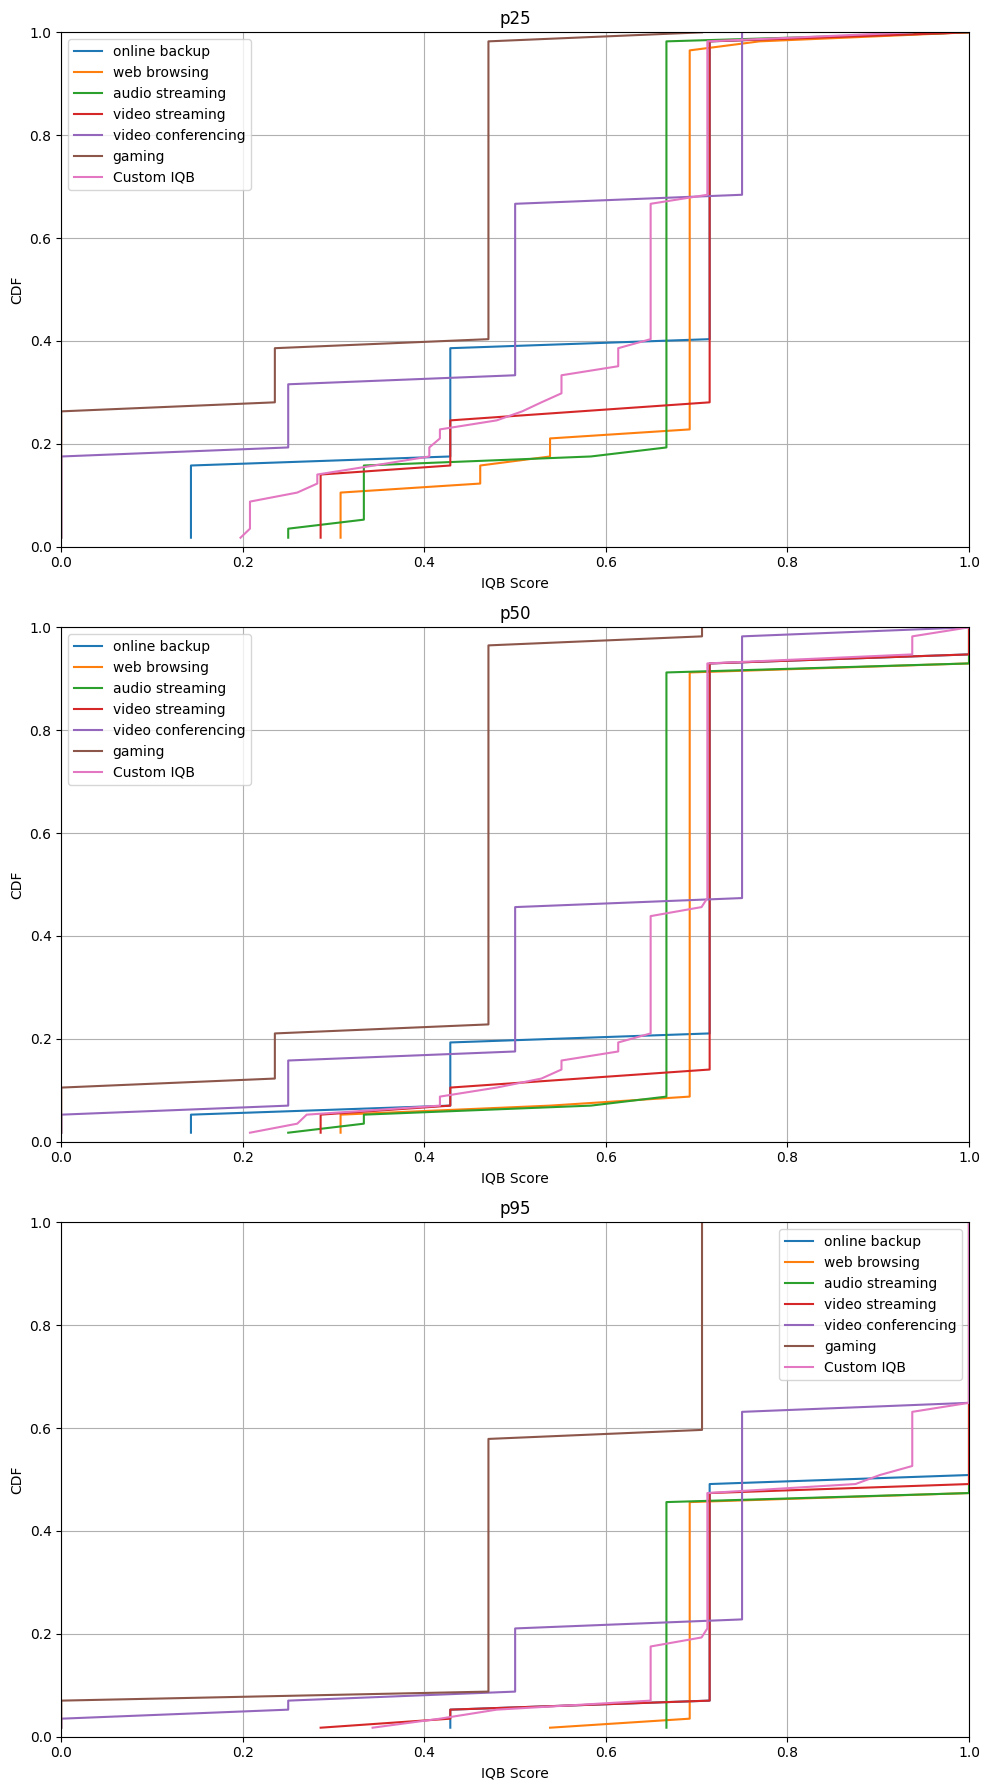

In [21]:
  
fig, axes = plt.subplots(len(PERCENTILES), 1, figsize=(10, 6 * len(PERCENTILES)))

for ax, perc in zip(axes, PERCENTILES):
    for uc in SORTED_IQB_USE_CASES:
        x_cdf, y_cdf = get_cdf(scores_df_uc[uc][f"iqb_score_p{perc}"])
        ax.plot(x_cdf, y_cdf, label=uc)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('IQB Score')
    ax.set_ylabel('CDF')
    ax.set_title(f'p{perc}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()



### 4.2 IQB scores per school

Heatmaps below show the IQB scores per use case, the custom IQB score, and the original IQB score for all schools

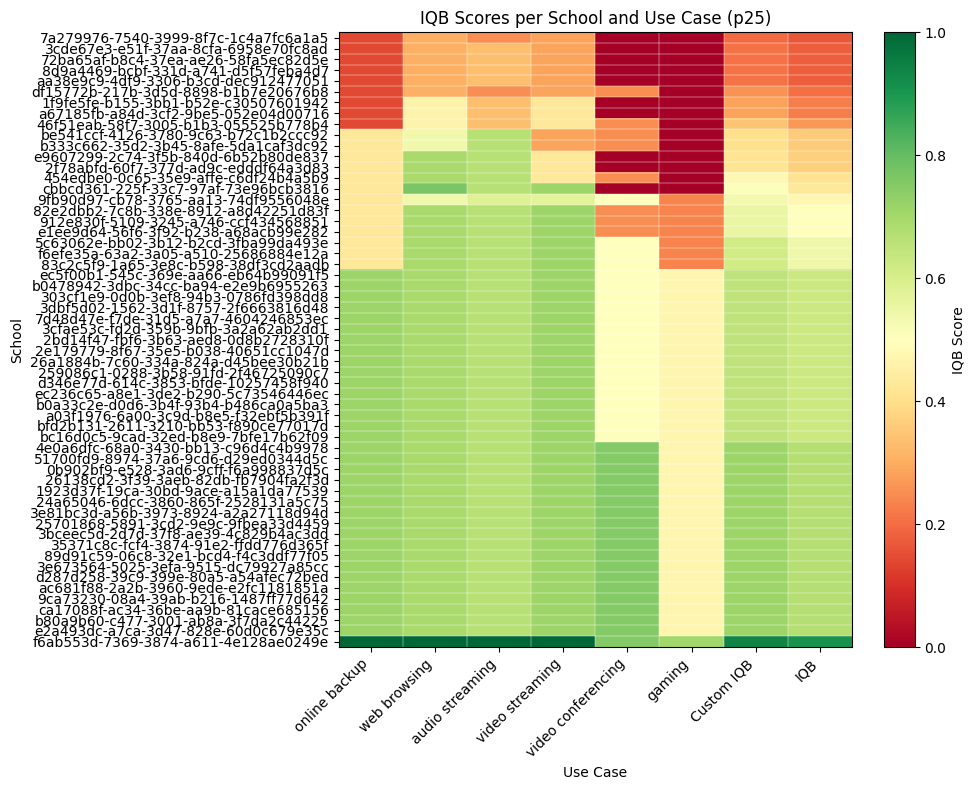

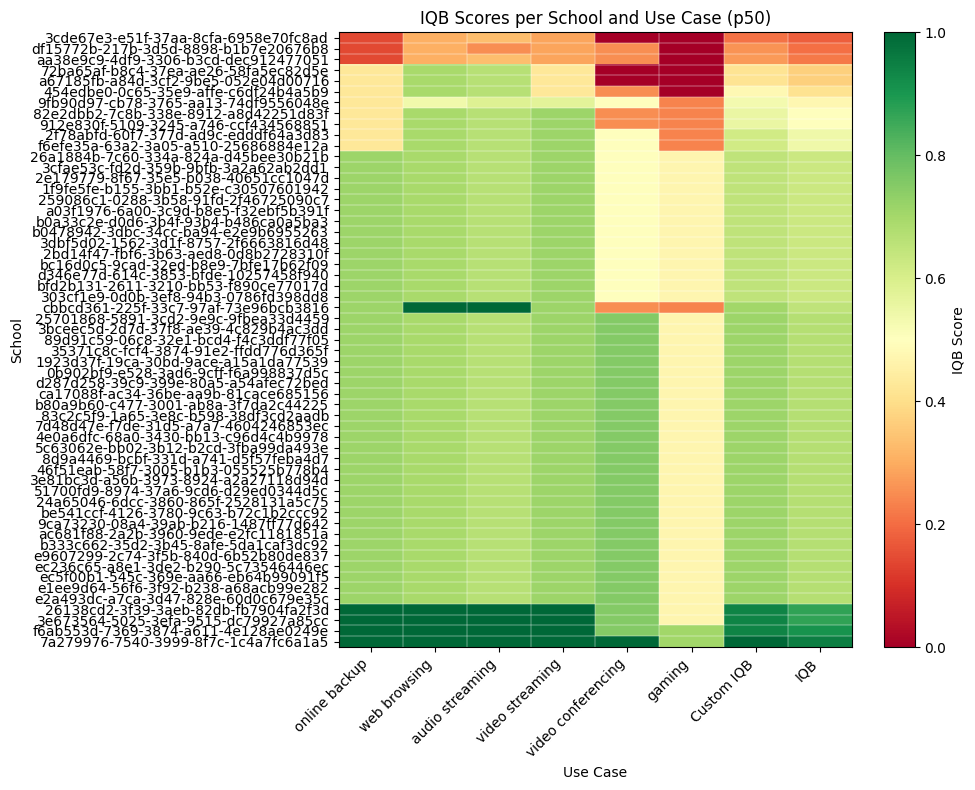

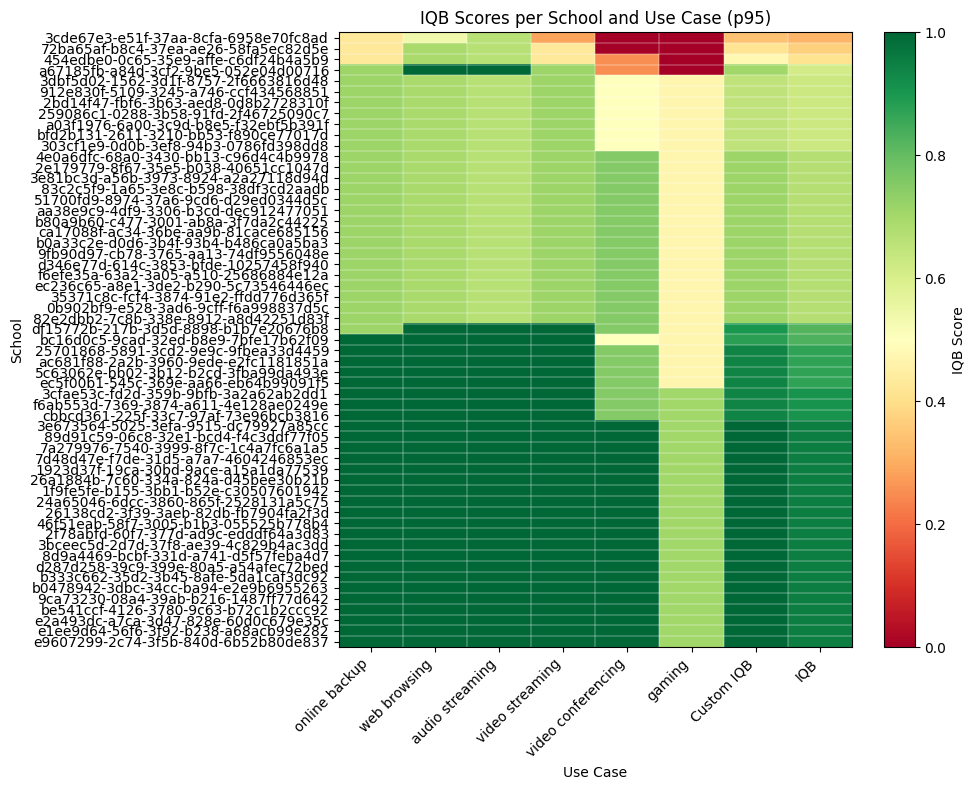

In [22]:
for perc in PERCENTILES:
    uc_matrix = pd.DataFrame({
        uc: scores_df_uc[uc].set_index("school_id")[f"iqb_score_p{perc}"]
        for uc in SORTED_IQB_USE_CASES
    })
    uc_matrix = uc_matrix.loc[uc_matrix.index.isin(scores_df["school_id"])]
    # uc_matrix = uc_matrix.sort_values("video conferencing")
    uc_matrix['IQB'] = uc_matrix[[c for c in IQB_USE_CASES]].mean(axis=1)
    uc_matrix = uc_matrix.sort_values("IQB")

    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(uc_matrix.values, aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")

    # Axes ticks
    ax.set_xticks(range(len(uc_matrix.columns)))
    ax.set_xticklabels(uc_matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(uc_matrix.index)))
    ax.set_yticklabels(uc_matrix.index)

    # Grid lines to mimic linewidths=0.3
    ax.set_xticks([x - 0.5 for x in range(1, len(uc_matrix.columns))], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, len(uc_matrix.index))], minor=True)
    ax.grid(which="minor", color="white", linewidth=0.3)
    ax.tick_params(which="minor", length=0)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("IQB Score")

    ax.set_title(f"IQB Scores per School and Use Case (p{perc})")
    ax.set_xlabel("Use Case")
    ax.set_ylabel("School")

    plt.tight_layout()
    plt.show()

## 5. School Characteristics

Load school metadata (`latitude` / `longitude`). 

Map of schools colored by IQB score. Geographic patterns can reveal regional infrastructure disparities — e.g., schools in urban centers vs. remote rural areas.

In [23]:
df_schools = pd.read_csv("./data/giga_MD_schools_metadata.csv")
df_schools.head()

,giga_id_school,latitude,longitude
0,0098e210-ef0d-337d-8602-e0e3358d5518,47.776390,27.796110
1,018a5893-a9fc-32c9-bb04-98027851bbea,48.302500,27.307200
2,0215f91d-9ee1-37a4-9271-96a03f529d64,47.252000,28.021000
3,02328b18-4e78-31b4-80a1-339d6ade0b95,46.672554,28.406118
4,024bfbbd-0564-37d5-b4b4-fac272e90017,46.187078,28.386687


Merge IQB scores with school metadata and M-Lab sample counts. 

In [24]:
df_full = pd.merge(scores_df, df_schools, on="giga_id_school", how="left")
df_full.head()

,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count,giga_id_school,iqb_score_diff_p95_p25,iqb_score_diff_p95_p50,latitude,longitude
0,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.178266,0.178266,0.319902,0.319902,0.319902,6,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.141636,0.141636,45.915325,28.215977
1,df15772b-217b-3d5d-8898-b1b7e20676b8,0.206044,0.206044,0.773028,0.822479,0.822479,205,df15772b-217b-3d5d-8898-b1b7e20676b8,0.616435,0.616435,47.041314,28.893493
2,aa38e9c9-4df9-3306-b3cd-dec912477051,0.178266,0.219933,0.668022,0.668022,0.668022,6,aa38e9c9-4df9-3306-b3cd-dec912477051,0.489756,0.448089,47.188750,27.810588
3,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.178266,0.369353,0.369353,0.369353,0.369353,27,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.191087,0.000000,46.991367,28.844834
4,a67185fb-a84d-3cf2-9be5-052e04d00716,0.227717,0.369353,0.411020,0.411020,0.613095,47,a67185fb-a84d-3cf2-9be5-052e04d00716,0.385379,0.243742,47.497782,28.368234


### 5.1 Average performance

In [25]:
fig = px.scatter_map(
    df_full.round(2).dropna(subset=["latitude", "longitude"]),
    lat="latitude",
    lon="longitude",
    color="iqb_score_p50",
    hover_data=["school_id", "download_sample_count"],
    color_continuous_scale="RdYlGn",
    size_max=50,
    range_color=[0, 1],
    zoom=6,
    title="IQB Score (p50) by School"
)
fig.show()

### 5.2 Capacity

In [26]:
fig = px.scatter_map(
    df_full.round(2).dropna(subset=["latitude", "longitude"]),
    lat="latitude",
    lon="longitude",
    color="iqb_score_p95",
    hover_data=["school_id", "download_sample_count"],
    color_continuous_scale="RdYlGn",
    size_max=50,
    range_color=[0, 1],
    zoom=6,
    title="IQB Score (p95) by School"
)
fig.show()

## 5.3 Schools with low IQB scores

In [27]:
df_full.sort_values(by='iqb_score_p50').head()

,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count,giga_id_school,iqb_score_diff_p95_p25,iqb_score_diff_p95_p50,latitude,longitude
0,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.178266,0.178266,0.319902,0.319902,0.319902,6,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.141636,0.141636,45.915325,28.215977
1,df15772b-217b-3d5d-8898-b1b7e20676b8,0.206044,0.206044,0.773028,0.822479,0.822479,205,df15772b-217b-3d5d-8898-b1b7e20676b8,0.616435,0.616435,47.041314,28.893493
2,aa38e9c9-4df9-3306-b3cd-dec912477051,0.178266,0.219933,0.668022,0.668022,0.668022,6,aa38e9c9-4df9-3306-b3cd-dec912477051,0.489756,0.448089,47.188750,27.810588
3,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.178266,0.369353,0.369353,0.369353,0.369353,27,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.191087,0.000000,46.991367,28.844834
4,a67185fb-a84d-3cf2-9be5-052e04d00716,0.227717,0.369353,0.411020,0.411020,0.613095,47,a67185fb-a84d-3cf2-9be5-052e04d00716,0.385379,0.243742,47.497782,28.368234


In [28]:
df_full.sort_values(by='iqb_score_p95').head()

,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p75,iqb_score_p90,iqb_score_p95,download_sample_count,giga_id_school,iqb_score_diff_p95_p25,iqb_score_diff_p95_p50,latitude,longitude
0,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.178266,0.178266,0.319902,0.319902,0.319902,6,3cde67e3-e51f-37aa-8cfa-6958e70fc8ad,0.141636,0.141636,45.915325,28.215977
3,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.178266,0.369353,0.369353,0.369353,0.369353,27,72ba65af-b8c4-37ea-ae26-58fa5ec82d5e,0.191087,0.000000,46.991367,28.844834
5,454edbe0-0c65-35e9-affe-c6df24b4a5b9,0.411020,0.411020,0.411020,0.411020,0.411020,34,454edbe0-0c65-35e9-affe-c6df24b4a5b9,0.000000,0.000000,47.848034,28.562896
4,a67185fb-a84d-3cf2-9be5-052e04d00716,0.227717,0.369353,0.411020,0.411020,0.613095,47,a67185fb-a84d-3cf2-9be5-052e04d00716,0.385379,0.243742,47.497782,28.368234
15,259086c1-0288-3b58-91fd-2f46725090c7,0.626356,0.626356,0.626356,0.626356,0.626356,7,259086c1-0288-3b58-91fd-2f46725090c7,0.000000,0.000000,48.032276,27.816067


## 6. Compare: Network metrics vs IQB scores

**Motivation questions**

- What is the effect of the network metrics to the IQB-Edu scores of schools? 
- While the detailed effect of network metrics to IQB score is defined in the IQB framework, what does that effect look like in practice when applied to the measurement results for Moldova schools?

**Findings**

We calculate correlations betwee IQB scores and the corresponding network metrics, for each considered percentile. Below we present the heatmap/correlations as well as scatter plots that show more detailed relationships between IQB scores and network metrics. 
(similar results hold for the custom IQB case; not shown in the plots)

The main findings are the following:

- Network metrics have very different effect on IQB scores, depending on the _metric_ & the _percentile_ considered
- There is _no clear linear relationship_ between a network metric and the IQB score
- All metrics affect the IQB scores
- _Capacity_ (i.e. 95th percentile) is mostly correlated to _packet loss_ 
- _Average performance_ (50th percentile) is correlated to _all metrics_
- _Worst case performance_ (25th percentile) is sligthly more correlated to _throughput_ metrics

In [29]:
# Merge network metrics at matching percentiles into scores_df
NET_METRICS = ["download", "upload", "latency", "loss"]
net_cols = (
    ["school_id"]
    + [f"{m}_p{p}" for m in NET_METRICS for p in PERCENTILES]
)
net_df = data.df[net_cols]
compare_df = pd.merge(scores_df, net_df, on="school_id", how="inner")

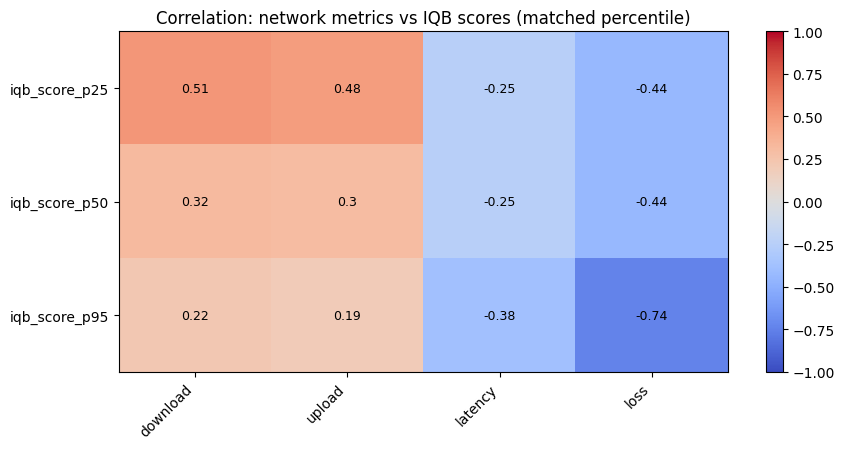

In [30]:
# Each iqb_score_pXX correlated only with {metric}_pXX
corr_data = {}
for perc in PERCENTILES:
    iqb_col = f"iqb_score_p{perc}"
    corr_data[iqb_col] = {
        metric: compare_df[[iqb_col, f"{metric}_p{perc}"]].corr().iloc[0, 1]
        for metric in NET_METRICS
    }

corr_sub = pd.DataFrame(corr_data).T.round(2)
# corr_sub: rows = iqb_score_pXX, columns = download/upload/latency/loss

fig, ax = plt.subplots(figsize=(len(NET_METRICS) * 2 + 1, len(PERCENTILES) * 1.2 + 1))
im = ax.imshow(corr_sub.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_sub.columns)))
ax.set_yticks(range(len(corr_sub.index)))
ax.set_xticklabels(corr_sub.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_sub.index)

for i in range(len(corr_sub.index)):
    for j in range(len(corr_sub.columns)):
        ax.text(j, i, str(corr_sub.iloc[i, j]),
                ha="center", va="center", fontsize=9)

ax.set_title("Correlation: network metrics vs IQB scores (matched percentile)")
plt.tight_layout()
plt.show()


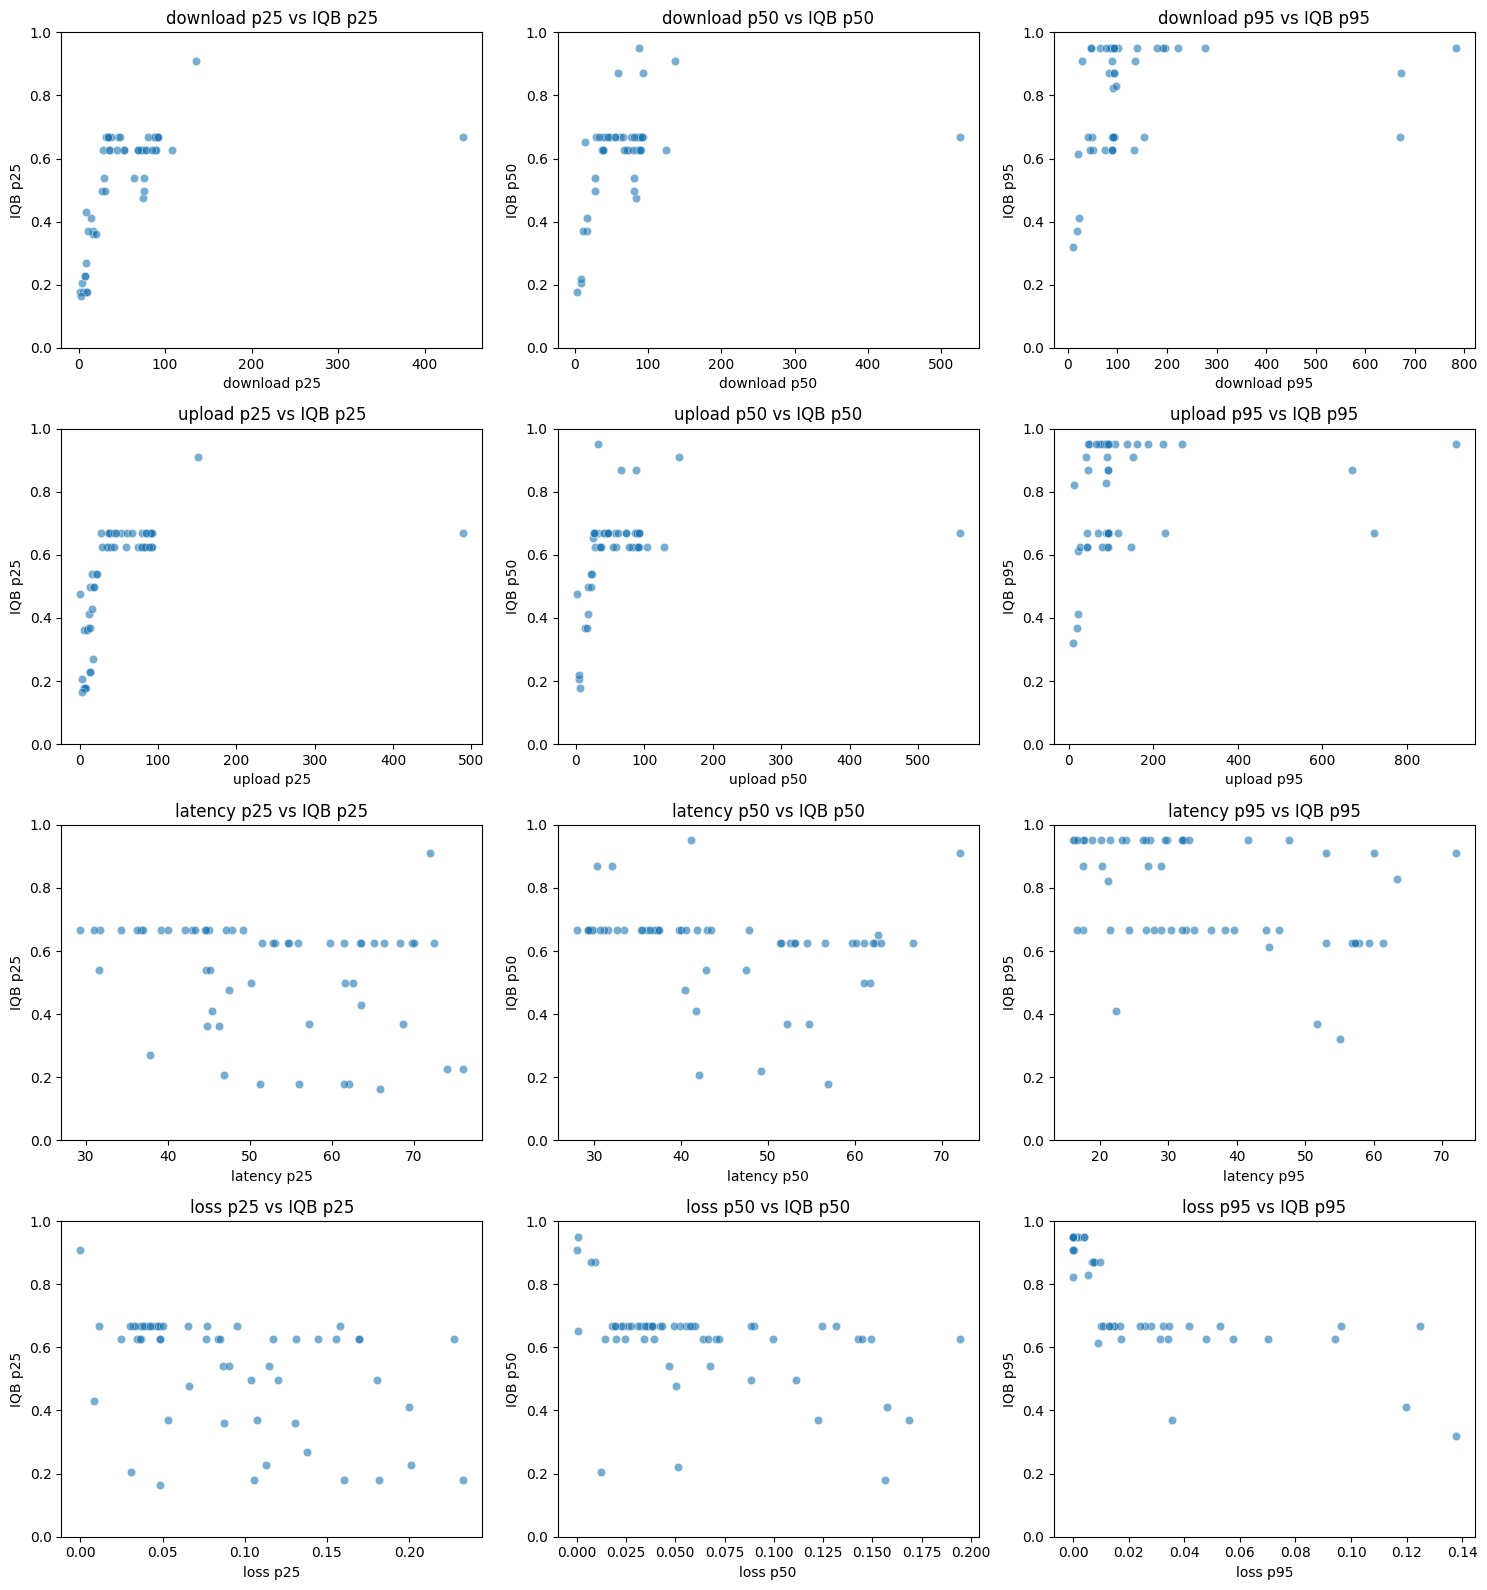

In [31]:
fig, axes = plt.subplots(len(NET_METRICS), len(PERCENTILES),
                         figsize=(5 * len(PERCENTILES), 4 * len(NET_METRICS)))

for row, metric in enumerate(NET_METRICS):
    for col, perc in enumerate(PERCENTILES):
        ax = axes[row, col]
        x = compare_df[f"{metric}_p{perc}"]
        y = compare_df[f"iqb_score_p{perc}"]
        ax.scatter(x, y, alpha=0.6, edgecolors="w", linewidths=0.4)
        ax.set_xlabel(f"{metric} p{perc}")
        ax.set_ylabel(f"IQB p{perc}")
        ax.set_ylim(0, 1)
        ax.set_title(f"{metric} p{perc} vs IQB p{perc}")

plt.tight_layout()
plt.show()


## Appendix A. Define custom thresholds

In [32]:
CUSTOM_CONFIG_WEIGHTS = {
    'online backup':0.5,
    'web browsing':1,
    'audio streaming':0.5,
    'video streaming':1,
    'video conferencing':1,
    'gaming':0}


CUSTOM_CONFIG_THRESHOLDS = {
    'online backup':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    },
    'web browsing':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    },
    'audio streaming':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    },
    'video streaming':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    },
    'video conferencing':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    },
    'gaming':{
        'download_throughput_mbps': 10,
        'upload_throughput_mbps':10,
        'latency_ms':100,
        'packet_loss':0.01
    }
    }

my_config = copy.deepcopy(IQB_CONFIG)

for uc in IQB_USE_CASES:
    my_config['use cases'][uc]['w'] = CUSTOM_CONFIG_WEIGHTS[uc]
    for metric in CUSTOM_CONFIG_THRESHOLDS[uc]:
        my_config['use cases'][uc]['network requirements'][metric]['threshold min'] = CUSTOM_CONFIG_THRESHOLDS[uc][metric]
    
my_iqb_calc = IQBCalculator(config = copy.deepcopy(my_config))

scores = []
for school_id in data.schools:
    score = {"school_id": school_id}
    for perc in PERCENTILES:
        mlab_data = data.to_iqb_data(school_id, percentile=perc)
        score[f"iqb_score_p{perc}"] = my_iqb_calc.calculate_iqb_score({"m-lab": mlab_data.to_dict()})
    scores.append(score)

my_scores_df = pd.DataFrame(scores)
my_scores_df.head()

,school_id,iqb_score_p25,iqb_score_p50,iqb_score_p95
0,0b902bf9-e528-3ad6-9cff-f6a998837d5c,0.711767,0.711767,0.711767
1,1923d37f-19ca-30bd-9ace-a15a1da77539,0.711767,0.711767,1.000000
2,1f9fe5fe-b155-3bb1-b52e-c30507601942,0.442766,0.711767,1.000000
3,24a65046-6dcc-3860-865f-2528131a5c75,0.711767,0.711767,1.000000
4,25701868-5891-3cd2-9e9c-9fbea33d4459,0.711767,0.711767,1.000000
